# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [2]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode
import statistics as stats

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título

In [3]:
df["title_lenght"] = df["title"].apply(len)
df["title_lenght"]

0      24
1      13
2      22
3      15
4      12
       ..
974     7
975    27
976    47
977    11
978    11
Name: title_lenght, Length: 979, dtype: int64

Calcula media, mediana y moda de la columna 'title_length'

In [4]:
media = np.mean(df["title_lenght"])
mediana = np.median(df["title_lenght"])
moda = mode(df["title_lenght"], keepdims=True).mode[0]

print(media)
print(mediana)
print(moda)

15.481103166496425
14.0
12


Calcula el rango, la varianza y la desviación estándar de 'title_length'

In [5]:
rango = np.max(df["title_lenght"]) - np.min(df["title_lenght"])
varianza = np.var(df["title_lenght"])
desviación = np.std(df["title_lenght"])

print(rango)
print(varianza)
print(desviación)

67
72.03309541223715
8.487231316055734


Calcula asimetría y curtosis de la columna 'title_length'

In [6]:
asimetría = skew(df["title_lenght"])
kurtosis = kurtosis(df["title_lenght"])

print(asimetría)
print(kurtosis)

1.5229143965677572
3.7867237597626007


Imprime el título más corto y el título más largo según su longitud

In [7]:
titulo_corto = df.loc[df["title_lenght"].idxmin(), "title"]
titulo_largo = df.loc[df["title_lenght"].idxmax(), "title"]

print(titulo_corto)
print(titulo_largo)

M
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb


Grafica tus resultados

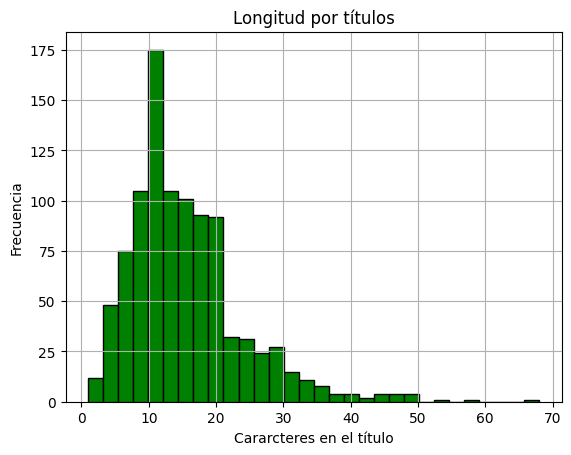

In [8]:
plt.hist(df["title_lenght"],
    bins = 30,
    color = 'green',
    edgecolor = 'black'
)
plt.title('Longitud por títulos')
plt.xlabel('Cararcteres en el título')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]

In [17]:
valores = [8, 22, 35, 13, 12]
print(valores)

[8, 22, 35, 13, 12]


Calcula la media de los 5 valores

In [10]:
media_valores = np.mean(valores)
print(media_valores)

18.0


Calcula las diferencias al cuadrado con respecto a la media

In [15]:
valores_dif = sum((i - media_valores)**2 for i in valores)
print(valores_dif)

466.0


Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación

In [16]:
varianza_valores = valores_dif / len(valores)
desviación_valores = varianza_valores ** 0.5

print(varianza_valores)
print(desviación_valores)

93.2
9.654014708917737
